In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load daily category performance data created in SQL
category = pd.read_csv("category_performance.csv")

# Convert Date to datetime format
category["Date"] = pd.to_datetime(category["Date"])

# Check dataset structure
print("Dataset shape:", category.shape)
category.head()

# Check data types and missing values
category.info()

print("\nMissing values:")
print(category.isna().sum())

Dataset shape: (5821, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5821 entries, 0 to 5820
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              5821 non-null   datetime64[ns]
 1   Year              5821 non-null   int64         
 2   Quarter           5821 non-null   int64         
 3   Month_Number      5821 non-null   int64         
 4   Month_Name        5821 non-null   object        
 5   Product_Category  5821 non-null   object        
 6   Units_Sold        5821 non-null   int64         
 7   Revenue           5821 non-null   float64       
 8   COGS              5821 non-null   float64       
 9   Gross_Profit      5821 non-null   float64       
 10  Gross_Margin      5821 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(2)
memory usage: 500.4+ KB

Missing values:
Date                0
Year                0
Quarter             0

In [3]:
# Aggregate category performance across the full year
category_summary = (
    category
    .groupby("Product_Category", as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        COGS=("COGS", "sum"),
        Gross_Profit=("Gross_Profit", "sum")
    )
)

# Calculate annual gross margin for each category
category_summary["Gross_Margin"] = (
    category_summary["Gross_Profit"] /
    category_summary["Revenue"]
)

# Sort categories by revenue
category_summary = category_summary.sort_values(
    "Revenue",
    ascending=False
)

category_summary

,Product_Category,Units_Sold,Revenue,COGS,Gross_Profit,Gross_Margin
0,Action Figures,52714,1060521.61,597803.40,462718.21,0.436312
15,Toy Vehicles,48772,809957.92,472569.77,337388.15,0.416550
13,Puzzles,43437,775226.80,407930.55,367296.25,0.473792
2,Baby & Toddler,48976,748379.58,423494.04,324885.54,0.434119
10,Outdoor Play,41484,738651.06,408192.57,330458.49,0.447381
14,STEM Kits,33254,674970.80,381184.51,293786.29,0.435258
1,Arts & Crafts,54206,671287.61,402718.27,268569.34,0.400081
8,Educational,36340,655321.97,370462.74,284859.23,0.434686
7,Dolls,33934,603208.39,333356.59,269851.80,0.447361
3,Board Games,34959,601058.23,333578.34,267479.89,0.445015


In [4]:
# Display categories ranked by annual revenue
category_summary[
    [
        "Product_Category",
        "Units_Sold",
        "Revenue",
        "Gross_Profit",
        "Gross_Margin"
    ]
]

,Product_Category,Units_Sold,Revenue,Gross_Profit,Gross_Margin
0,Action Figures,52714,1060521.61,462718.21,0.436312
15,Toy Vehicles,48772,809957.92,337388.15,0.416550
13,Puzzles,43437,775226.80,367296.25,0.473792
2,Baby & Toddler,48976,748379.58,324885.54,0.434119
10,Outdoor Play,41484,738651.06,330458.49,0.447381
14,STEM Kits,33254,674970.80,293786.29,0.435258
1,Arts & Crafts,54206,671287.61,268569.34,0.400081
8,Educational,36340,655321.97,284859.23,0.434686
7,Dolls,33934,603208.39,269851.80,0.447361
3,Board Games,34959,601058.23,267479.89,0.445015


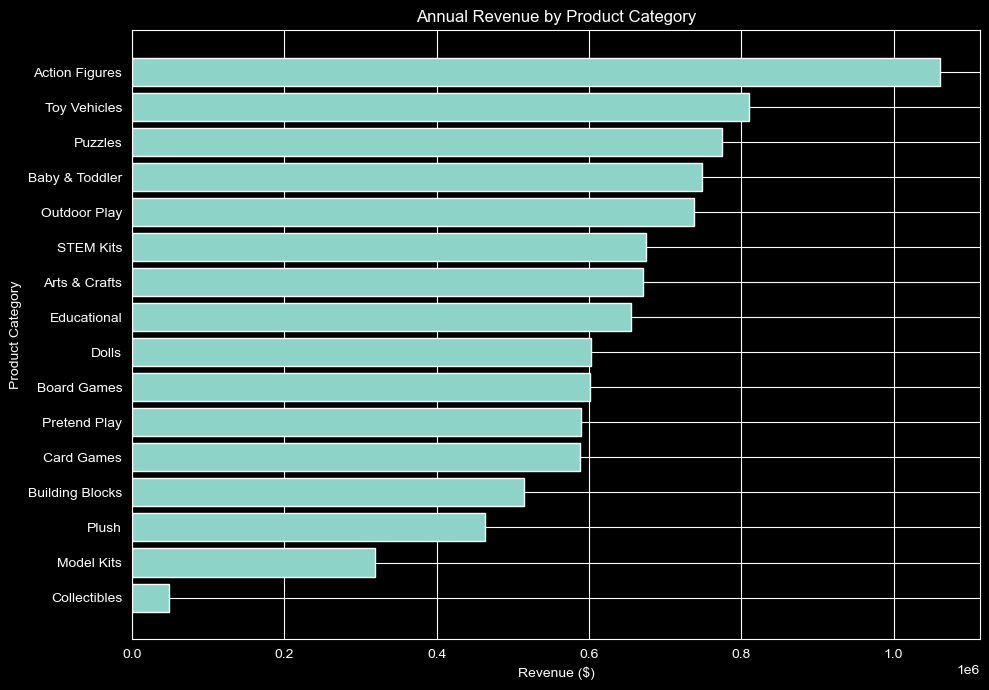

In [5]:
# Plot annual revenue by product category
category_plot = category_summary.sort_values(
    "Revenue",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    category_plot["Product_Category"],
    category_plot["Revenue"]
)
plt.title("Annual Revenue by Product Category")
plt.xlabel("Revenue ($)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

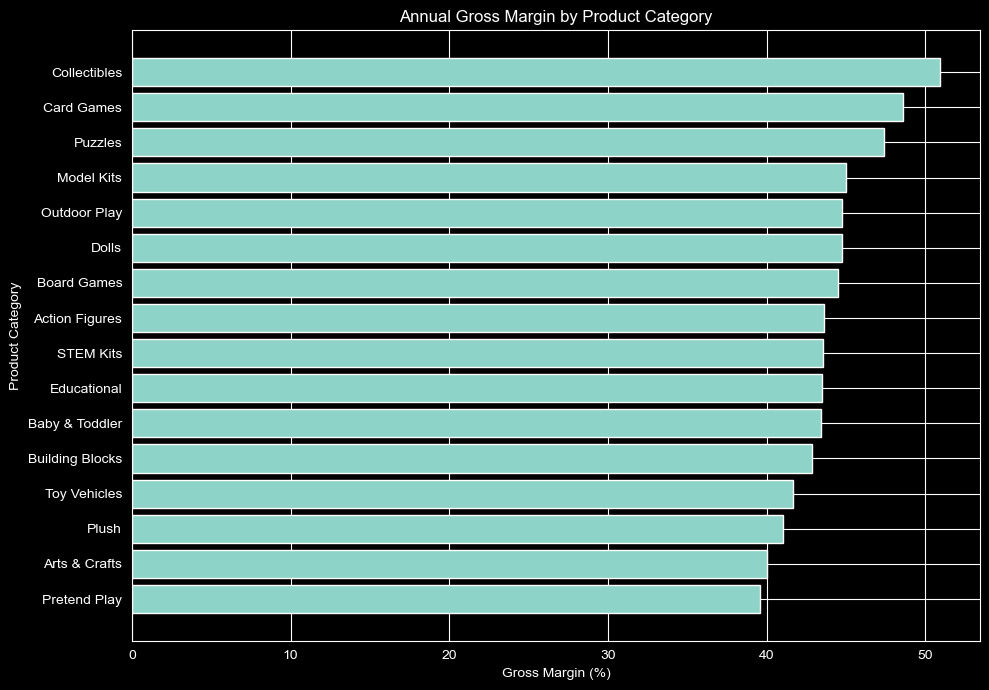

In [6]:
# Plot annual gross margin by product category
margin_plot = category_summary.sort_values(
    "Gross_Margin",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    margin_plot["Product_Category"],
    margin_plot["Gross_Margin"] * 100
)
plt.title("Annual Gross Margin by Product Category")
plt.xlabel("Gross Margin (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [8]:
# Calculate revenue and gross margin benchmarks for category segmentation
revenue_median = category_summary["Revenue"].median()
margin_median = category_summary["Gross_Margin"].median()

# Classify categories into four business segments
def classify_category(row):
    if row["Revenue"] >= revenue_median and row["Gross_Margin"] >= margin_median:
        return "High Revenue / High Margin"
    elif row["Revenue"] >= revenue_median and row["Gross_Margin"] < margin_median:
        return "High Revenue / Low Margin"
    elif row["Revenue"] < revenue_median and row["Gross_Margin"] >= margin_median:
        return "Low Revenue / High Margin"
    else:
        return "Low Revenue / Low Margin"

category_summary["Segment"] = category_summary.apply(
    classify_category,
    axis=1
)

# Display the category segmentation
category_summary[
    [
        "Product_Category",
        "Revenue",
        "Gross_Margin",
        "Gross_Profit",
        "Segment"
    ]
].sort_values("Revenue", ascending=False)

,Product_Category,Revenue,Gross_Margin,Gross_Profit,Segment
0,Action Figures,1060521.61,0.436312,462718.21,High Revenue / High Margin
15,Toy Vehicles,809957.92,0.416550,337388.15,High Revenue / Low Margin
13,Puzzles,775226.80,0.473792,367296.25,High Revenue / High Margin
2,Baby & Toddler,748379.58,0.434119,324885.54,High Revenue / Low Margin
10,Outdoor Play,738651.06,0.447381,330458.49,High Revenue / High Margin
14,STEM Kits,674970.80,0.435258,293786.29,High Revenue / Low Margin
1,Arts & Crafts,671287.61,0.400081,268569.34,High Revenue / Low Margin
8,Educational,655321.97,0.434686,284859.23,High Revenue / Low Margin
7,Dolls,603208.39,0.447361,269851.80,Low Revenue / High Margin
3,Board Games,601058.23,0.445015,267479.89,Low Revenue / High Margin


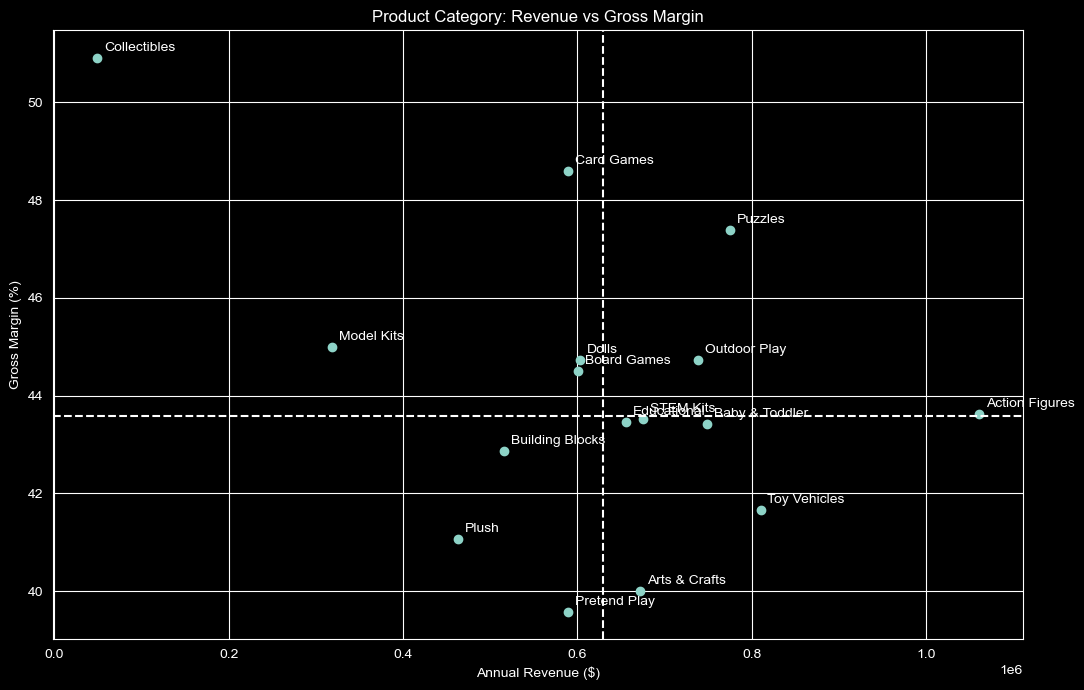

In [9]:
# Plot revenue versus gross margin for all product categories
plt.figure(figsize=(11, 7))

plt.scatter(
    category_summary["Revenue"],
    category_summary["Gross_Margin"] * 100
)

# Add category labels to each point
for _, row in category_summary.iterrows():
    plt.annotate(
        row["Product_Category"],
        (row["Revenue"], row["Gross_Margin"] * 100),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Add median reference lines
plt.axvline(revenue_median, linestyle="--")
plt.axhline(margin_median * 100, linestyle="--")

plt.title("Product Category: Revenue vs Gross Margin")
plt.xlabel("Annual Revenue ($)")
plt.ylabel("Gross Margin (%)")
plt.tight_layout()
plt.show()